
# Course/Program Name: Summer Training and Internship on Machine Learning and Agentic AI
# Name: Shubham Ghosh Roy
## Date: 09 June, 2026

## Problem Statement
#### Predict the sale price of a house in King County (Ames Housing Data) using structural, locational, and sale-time features — through EDA and preprocessing only, without training any model.

## Dataset Citation and Licenses

### Dataset from Kaggle link: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction
#### Credit to Author 'harlfoxem'
#### License: CC0: Public Domain

### Also, Github Mirror at: (https://github.com/AkashSDas/house-sales-in-king-country-usa)
#### Credit to Author 'AkashSDas'
#### License: Apache 2.0 License

## Setup and Reproducibility

### Importing the Libraries

In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
%matplotlib inline

In [7]:
np.random.seed(42)

## Data Loading

### Importing the csv file and loading it into the DataFrame.
Using the Relative Path of the csv file

In [95]:
df = pd.read_csv('kc_house_data.csv')

In [96]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [97]:
df.shape

(21613, 21)

We can infer that the dataframe has 21613 records and 21 features. It means we have ample data to realize the housing price trends and forecaste data in King County, USA. Next, we will check the basic details of the dataset like the datatype of the columns and whether it has Null values.

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

##### We can infer that the dataset has no Null or NaN values, and it consists of 5 columns of the float datatype, 15 columns of the int datatype, and 1 column of the string datatype. We can also see that the date column is of string datatype, which would imply that we need to convert it into a datetime object in the future. We now have a rough idea about the dataset. We will next try to have an idea about the values of the dataset.

In [99]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


We get an idea about the average, minimum, maximum values, and interquartile ranges of the numerical columns like the price, number of bedrooms, bathrooms, etc. This gives us an idea about the metrics of the business we are associated with.

## Schema and Quality Audit

In [100]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

We can confirm that there are no null values in any of the records of the columns. Therefore, we will not need to clean the data before using it.Next, we will again check the datatype of the columns.

In [17]:
df.dtypes

id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

We can confirm that the datatype of the columns are float, integer and string. The column 'date' has an unconventional datatype, that could be converted.

In [43]:
print(df.duplicated().sum())

0


This proves that there is no duplicate record in the dataset. This is good for the dataset. Next, we check if the 'id' column of the dataframe has only unique values or if there are mulitple records with the same id.

In [34]:
df['id'].is_unique

False

In [44]:
print(df['id'].duplicated().sum())

177


The above two cells, help us realize that there are 177 records with the same 'id'. Now, this proves that there are houses that have been resold again. Next, we start some Exploratory Data Analysis.

## Exploratory Data Analysis

Now, we start on performing more in depth analysis. To start with we can get the names of the columns of the dataset.

In [50]:
columns = df.columns
print(columns)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')


In [68]:
price_mean = df['price'].mean()
price_median = df['price'].median()

In [69]:
print(price_mean)

540088.1417665294


In [70]:
print(price_median)

450000.0


In [83]:
print(df['price'].max())

7700000.0


In [84]:
print(df['price'].min())

75000.0


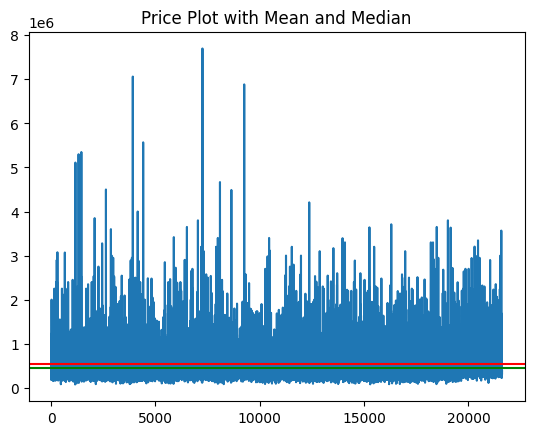

In [234]:
plt.plot(df['price'])
plt.axhline(price_mean, color='red', label=f'Mean: {price_mean:,.0f}')
plt.axhline(price_median, color='green', label=f'Median: {price_median:,.0f}')
plt.title("Price Plot with Mean and Median")
plt.show()

The values of mean and median are not equal therefore it means that the data is skewed. It is because of the luxury houses with extremely high pricing that is skewing the data.

In [107]:
print(df[columns].nunique()*100/len(df))

id               99.181048
date              1.721186
price            18.636931
bedrooms          0.060149
bathrooms         0.138805
sqft_living       4.802665
sqft_lot         45.259797
floors            0.027761
waterfront        0.009254
view              0.023134
condition         0.023134
grade             0.055522
sqft_above        4.376995
sqft_basement     1.415815
yr_built          0.536714
yr_renovated      0.323879
zipcode           0.323879
lat              23.291538
long              3.479387
sqft_living15     3.595059
sqft_lot15       40.202656
dtype: float64


We checked the cardanility of the columns in the above cells. After getting the number of unique values in each column, we divided each record by the total number of rows, to get the Cardanility Ratio. This gives us an idea that, we can use One-Hot Encoding format for the columns with percentages less than 1. And, use Embeddings in the other columns to give us proper scaling.

In [119]:
df.select_dtypes(exclude='str').corr()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


The above cell gives us the correlation between the numeric datatypes in the dataset. The correlation value ranges from -1 to 1. Although, it is difficult to infer any meaningful conclusion from the above matrix due to visual toughness. We can try to plot a heatmap depending the correlation between the datasets, to get a visual understanding of the data.

Text(0.5, 1.0, 'Correlation Heatmap')

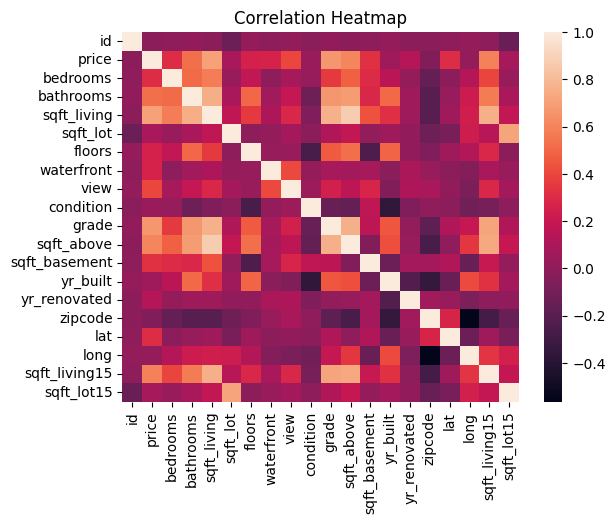

In [233]:
sns.heatmap(df.select_dtypes(exclude='str').corr())
plt.title("Correlation Heatmap")

The heatmap above gives us a better visual understanding of the correlation between the data. This gives us a rough idea about the relation between the data with a quick look. Next, we can try to conclude which features have the most effect on the price.

In [142]:
price_corr = df.select_dtypes(exclude='str').corr()['price']
print(price_corr>0.5)

id               False
price             True
bedrooms         False
bathrooms         True
sqft_living       True
sqft_lot         False
floors           False
waterfront       False
view             False
condition        False
grade             True
sqft_above        True
sqft_basement    False
yr_built         False
yr_renovated     False
zipcode          False
lat              False
long             False
sqft_living15     True
sqft_lot15       False
Name: price, dtype: bool


The above output gives us mainly 5 features that highly correlate to the price column, correlation is above 0.5. This provides very insightful information to a business about the features that have a high factor into the price of a housing listing. Next, we can check if the neighbourhood (zip Code) factors into the price of the house.

In [157]:
df['zipcode'].value_counts()

zipcode
98103    602
98038    590
98115    583
98052    574
98117    553
        ... 
98102    105
98010    100
98024     81
98148     57
98039     50
Name: count, Length: 70, dtype: int64

This gives us an idea of the density of the houses by the zip code. This helps our business understand the demand of certain zip codes over the others. Next, we check grade acts like a monotonic price driver.

In [164]:
grade_price = df.groupby('grade')['price'].agg(['count','median','mean']).reset_index()

Text(0.5, 1.0, 'Bar graph of Grade')

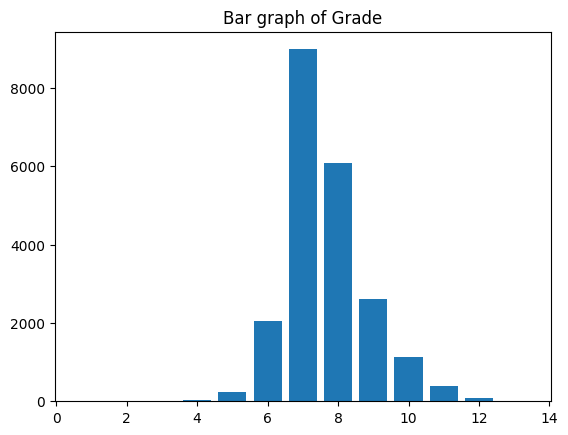

In [232]:
plt.bar(x=grade_price['grade'], height = grade_price['count'])
plt.title("Bar graph of Grade")

The above graph gives us the number of houses per grade. It shows us that most houses in the dataset are of grade 7 and grade 8 quality. This gives our business an idea about the expected grade or quality of the masses. Next, we can check if grade directly factors into the price of the house.

Text(0.5, 1.0, 'Trend of price of houses according to increasing Grade')

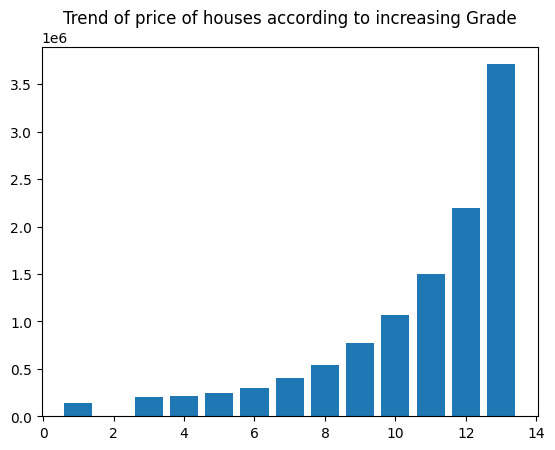

In [230]:
plt.bar(x=grade_price['grade'], height = grade_price['mean'])
plt.title("Average price of houses according to increasing Grade")

Text(0.5, 1.0, 'Median price of houses in each Grade')

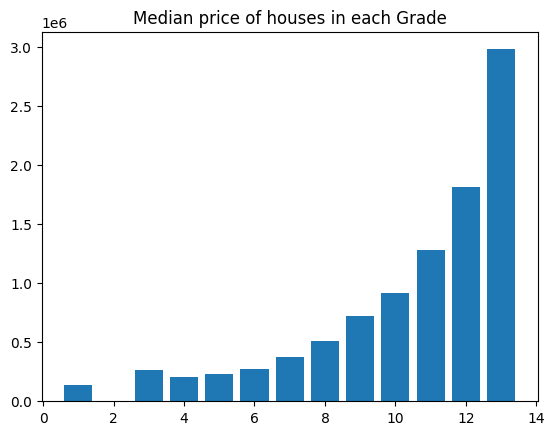

In [231]:
plt.bar(x=grade_price['grade'], height = grade_price['median'])
plt.title("Median price of houses in each Grade")

The two above graphs clearly show us that, higher the grade of the house, higher is the price of the house. The exponential increase in the mean and median prices of the houses as the grade increases gives our business an idea of the high market value of high grade homes.

In [184]:
df['waterfront'].value_counts()

waterfront
0    21450
1      163
Name: count, dtype: int64

In [185]:
df.groupby('waterfront')['price'].mean()

waterfront
0    5.315636e+05
1    1.661876e+06
Name: price, dtype: float64

We can infer from the above two cells that, there are only two types of houses, one with a waterfront, and one without. The houses with waterfront will directly increase the average price of the houses. As we can check, that the houses with waterfront have a mean price of about 1.66*(10)^6 against 5.3*(10)^5. This tells our business that houses with waterfronts have more average price. Next, we can check the outliers in the dataset.

In [193]:
q1 = df['price'].quantile(0.25)
q2 = df['price'].quantile(0.75)

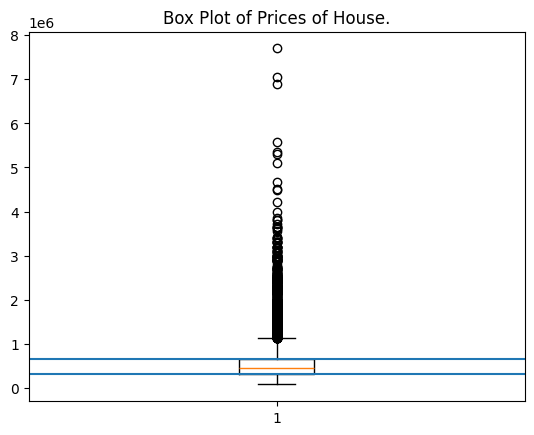

In [229]:
plt.boxplot(df['price'])
plt.axhline(q1)
plt.axhline(q2)
plt.title("Box Plot of Prices of House.")
plt.show()

From the box plot of the price, and the interquartile ranges we can see that the data has a lot of outliers. The outliers are basically the high grade luxury homes, that has caused the data to be skewed towards the right. Next, we can checkout the prices of house with respect to the number of houses in the same range.

Text(0.5, 1.0, 'Count of houses according to the price range.')

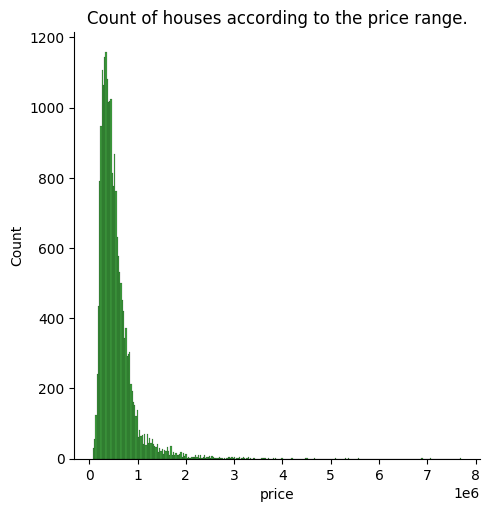

In [228]:
sns.displot(df, x='price', color='green')
plt.title('Count of houses according to the price range.')

The above plot further helps us visualize that there exists a good number of outliers, that skews the data towards the right. This helps us understand that the predicted price of a house is not completely linear, but has a bit of curve at the higher lifestyle, like waterfront, grade, etc. Next, we can visualize the price with respect to other factors such as area of the house, number of floors, number of bedrooms and bathrooms, etc. This wll help our business understand more of the market demands and prices.

Text(0.5, 1.0, 'Number of houses built in the last century by year.')

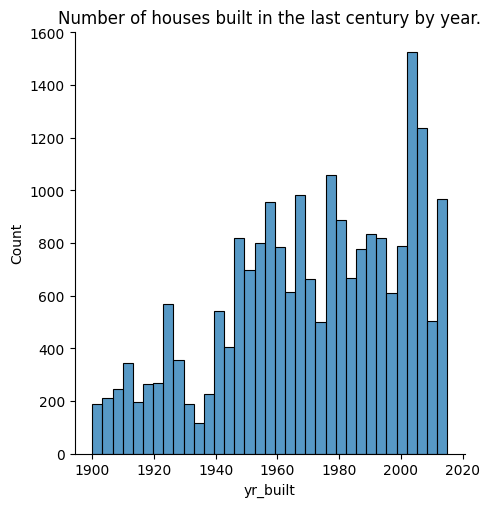

In [227]:
sns.displot(df, x='yr_built')
plt.title("Number of houses built in the last century by year.")

This shows that most of the houses sold is build in the last two decades. This provides our business with valuable information regarding the build and make of the houses.

Text(0.5, 1.0, 'Number of Floors vs Number of Houses')

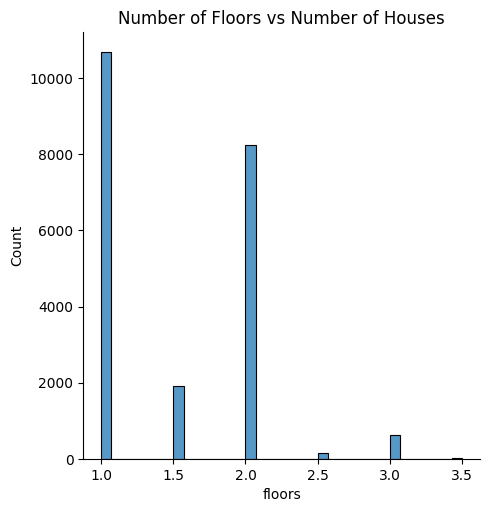

In [224]:
sns.displot(df, x='floors')
plt.title("Number of Floors vs Number of Houses")

Text(0.5, 1.0, 'Number of Bathrooms vs Number of Houses')

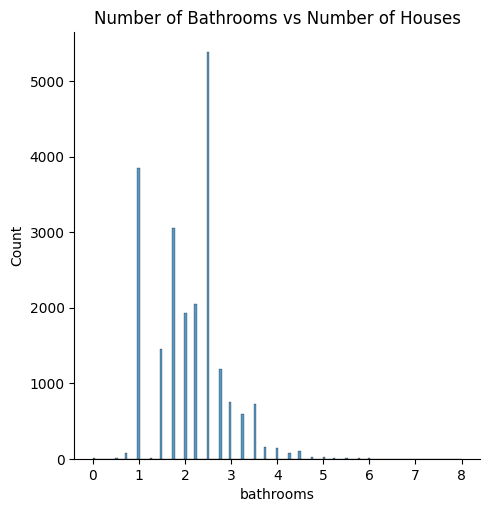

In [222]:
sns.displot(df, x='bathrooms')
plt.title('Number of Bathrooms vs Number of Houses')

Text(0.5, 1.0, 'Number of Bedrooms vs Number of Houses')

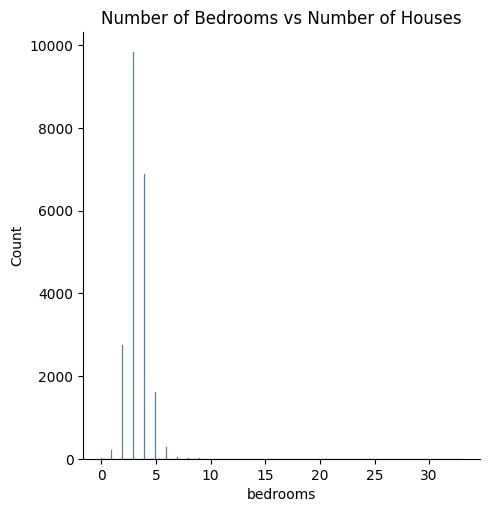

In [223]:
sns.displot(df, x='bedrooms')
plt.title("Number of Bedrooms vs Number of Houses")

The above plots show that most of the data belongs to 1 floored houses, 2-3 bedrooms and 2-3 bathrooms. This provides our business with valuable requirements for the business.

Now, After performing Exploratory Data Analysis, we can conclude that we have a brief understanding of the data, and the market. And, that the dataset is clean enough to perform Regression on it without any further cleaning required.  

## Data Pre-processing and Standardizing

We use the train_test_split function in the sklearn.model_selection modue that will split the data into train and test, in order to perform the regression analysis.

We have seen earlier in the data, that it has an uneven scaling. This can cause issues in the linear regression model. Thus, we use StandardScaler from sklearn, in order properly scale the data. 

#### We only use StandardScaler after we have split the data to control data leakage.

In [239]:
train, test = train_test_split(df, test_size=0.25, random_state=42)

We have used random_state = 42 in order to retain consistency.

In [240]:
train

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
5945,9117000170,20150505T000000,268643.0,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
8423,6700390210,20140708T000000,245000.0,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
13488,7212660540,20150115T000000,200000.0,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
20731,8562780200,20150427T000000,352499.0,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
2358,7760400350,20141205T000000,232000.0,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,5272200045,20141113T000000,378000.0,3,1.50,1000,6914,1.0,0,0,...,7,1000,0,1947,0,98125,47.7144,-122.319,1000,6947
21575,9578500790,20141111T000000,399950.0,3,2.50,3087,5002,2.0,0,0,...,8,3087,0,2014,0,98023,47.2974,-122.349,2927,5183
5390,7202350480,20140930T000000,575000.0,3,2.50,2120,4780,2.0,0,0,...,7,2120,0,2004,0,98053,47.6810,-122.032,1690,2650
860,1723049033,20140620T000000,245000.0,1,0.75,380,15000,1.0,0,0,...,5,380,0,1963,0,98168,47.4810,-122.323,1170,15000


In [241]:
test

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
735,2591820310,20141006T000000,365000.0,4,2.25,2070,8893,2.0,0,0,...,8,2070,0,1986,0,98058,47.4388,-122.162,2390,7700
2830,7974200820,20140821T000000,865000.0,5,3.00,2900,6730,1.0,0,0,...,8,1830,1070,1977,0,98115,47.6784,-122.285,2370,6283
4106,7701450110,20140815T000000,1038000.0,4,2.50,3770,10893,2.0,0,2,...,11,3770,0,1997,0,98006,47.5646,-122.129,3710,9685
16218,9522300010,20150331T000000,1490000.0,3,3.50,4560,14608,2.0,0,2,...,12,4560,0,1990,0,98034,47.6995,-122.228,4050,14226
19964,9510861140,20140714T000000,711000.0,3,2.50,2550,5376,2.0,0,0,...,9,2550,0,2004,0,98052,47.6647,-122.083,2250,4050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11144,7732500270,20140925T000000,650000.0,4,2.50,2820,15000,2.0,0,0,...,9,2820,0,1985,0,98052,47.7255,-122.101,2440,15000
17803,3856903515,20141222T000000,705000.0,3,2.00,1460,6250,1.5,0,0,...,7,1460,0,1912,0,98103,47.6693,-122.333,1690,4750
268,2557000400,20150409T000000,272500.0,3,2.50,2070,9900,1.0,0,0,...,8,1420,650,1979,0,98023,47.2988,-122.371,2070,8250
518,4386700135,20141114T000000,2250000.0,4,2.25,4760,8036,2.5,0,0,...,9,3390,1370,1916,0,98112,47.6415,-122.285,2950,9323


Our train and test datasets are successfully produced from the main dataframe df.

Next, for scaling we can use StandardScaler() to create an scaler object, and then call the fit_transform function to fit and transform the data according to the scaling.

However, since we are not supposed to be fitting a model in this notebook, I will not be scaling the train dataset.

## Summary:

### 5 Key Findings:
From the dataset, we can conclude the following points for our business:
1. The price of the houses depend majorly on the factors, Grade/Quality of the house, the sqaure feet of area for living and basement purposes, and also on the number of bathrooms.
2. Although, factors like waterfronts, number of bedrooms, floors, do result in the price of the house, their role in not as great as the factors mentioned above.
3. Factors like the Latitude and Longitude, do not result in much deviance from the expected price.
4. We realize that there is a huge number of outliers, which will result in a bad prediction model because, the data is rightly skewed, which means that the mean is right of the median. This happens because of the huge number of outliers. The outliers increase the mean of the population, while the median remains the same.
5. We have found 177 duplicate ids in the dataset, which suggests that there 177 houses that have be resold after being bought once.

### Our 3 Next Steps:
1. After this, we will seperate the price column from the dataset into a 'x' and 'y' objects, wherein 'x' will represent the independent features, and 'y' will represent the price or the dependent feature.
2. After seperating into x and y, we will use StandardScaler function from the sklearn.preprocessing module to properly scale the data according to it's mean and standard deviation.
3. After seperating into X_train, X_test, y_train, y_test, we will then create a Linear Regression object using the sklear.linear_model module. Then, we will fit our training data into the model.